In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.gridspec as gridspec

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Read csv
df = pd.read_csv('medical_time_series.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Day      731 non-null    int64  
 1   Revenue  731 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 11.6 KB


In [4]:
# Set a start date in datetime format
start_date = pd.to_datetime('2008-01-01')
# Convert Day column to differences in time
df['Date'] = pd.to_timedelta(df['Day']-1, unit='D') + start_date
# Drop 'Day' coloumn
df.drop('Day', axis=1, inplace=True)
# With datetime column properly established, set this as index
df.set_index('Date', inplace=True)
# Print new df
df

,Revenue
Date,
2008-01-01,0.000000
2008-01-02,-0.292356
2008-01-03,-0.327772
2008-01-04,-0.339987
2008-01-05,-0.124888
...,...
2009-12-27,15.722056
2009-12-28,15.865822
2009-12-29,15.708988


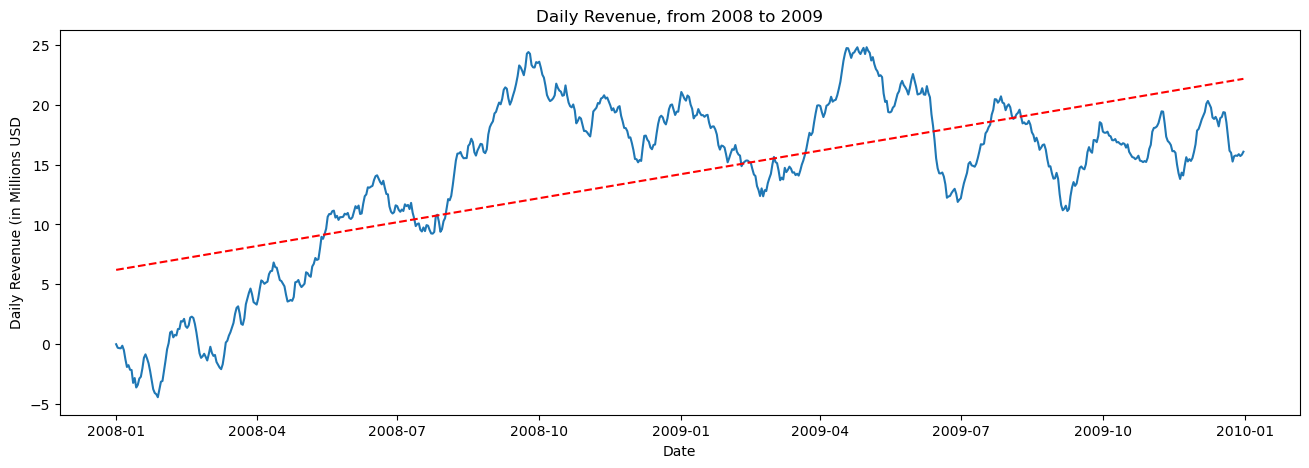

In [5]:
# Plot time series model
plt.figure(figsize = [16,5])
plt.title("Daily Revenue, from 2008 to 2009")
plt.xlabel("Date")
plt.ylabel("Daily Revenue (in Millions USD")
plt.plot(df)
# Generate trend line
x = mdates.date2num(df.index)
y = df.Revenue
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
# Plot graph
plt.plot(x, p(x), "r--")
plt.show()

In [6]:
# Perform Augmented Dicky-Fuller
adfuller_results = adfuller(df.Revenue)
# Print results
print(f"The test statistic of Dickey-Fuller test on this data is {round(adfuller_results[0], 4)}, which has a p-value of {round(adfuller_results[1], 4)}")

The test statistic of Dickey-Fuller test on this data is -2.2183, which has a p-value of 0.1997


The test statistic of an augmented Dickey-Fuller test on this data is -17.3748, which has a p-value of 0.0


<Axes: xlabel='Date'>

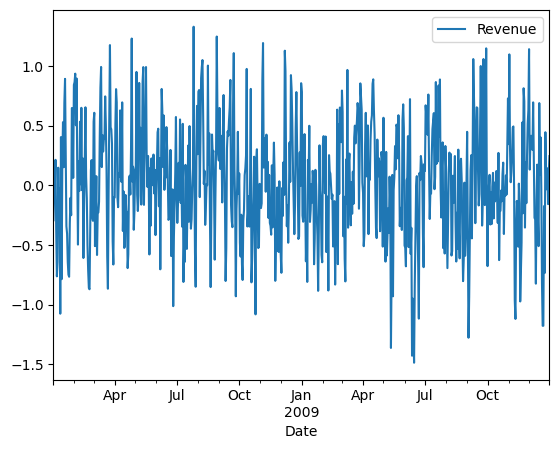

In [7]:
# Take the difference of the dataset
df_trans = df.diff().dropna()
# Perform Augmented Dickey-Fuller on data
adfuller_results = adfuller(df_trans['Revenue'])
# Print results
print(f"The test statistic of an augmented Dickey-Fuller test on this data is {round(adfuller_results[0], 4)}, which has a p-value of {round(adfuller_results[1], 8)}")
# Plot to check data is stationary
df_trans.plot()

In [8]:
# Split time series into a training set and a test set
train, test = train_test_split(df_trans, test_size=0.2, shuffle=False, random_state=369)
train

,Revenue
Date,
2008-01-02,-0.292356
2008-01-03,-0.035416
2008-01-04,-0.012215
2008-01-05,0.215100
2008-01-06,-0.366702
...,...
2009-08-03,-0.694370
2009-08-04,-0.282765
2009-08-05,0.104732


In [9]:
test

,Revenue
Date,
2009-08-08,0.263991
2009-08-09,-0.588690
2009-08-10,-0.550427
2009-08-11,0.081477
2009-08-12,-0.146587
...,...
2009-12-27,-0.032693
2009-12-28,0.143766
2009-12-29,-0.156834


In [10]:
# Save train dataframe to CSV
train.to_csv('d213_task1_train_clean.csv')
# Save test dataframe to CSV
test.to_csv('d213_task1_test_clean.csv')

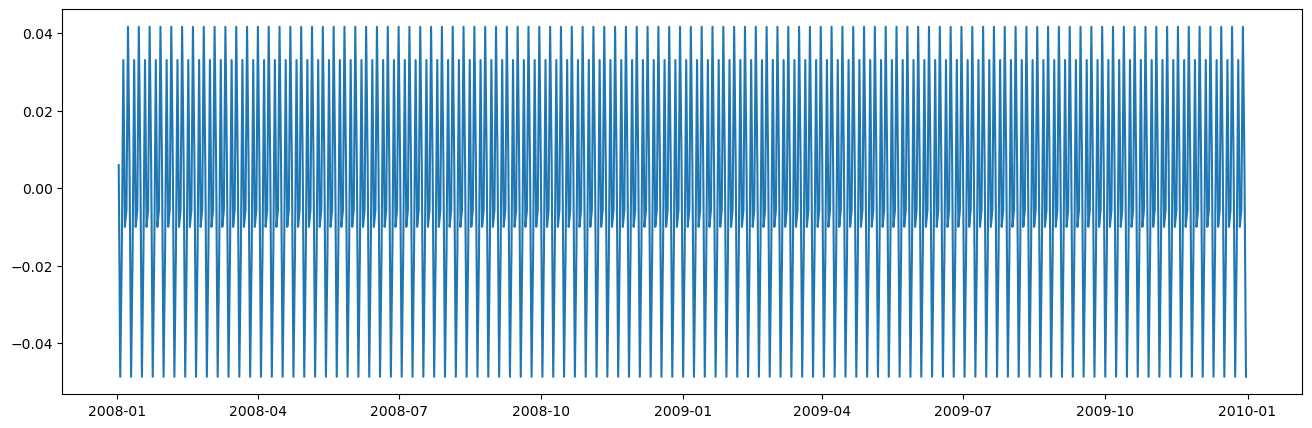

In [11]:
# Decompose the transformed data
decomposed_data = seasonal_decompose(df_trans)
# Long X and small Y dictate a wide graph figure
plt.figure(figsize = [16,5])
# Plot seasonal component of the data
plt.plot(decomposed_data.seasonal)

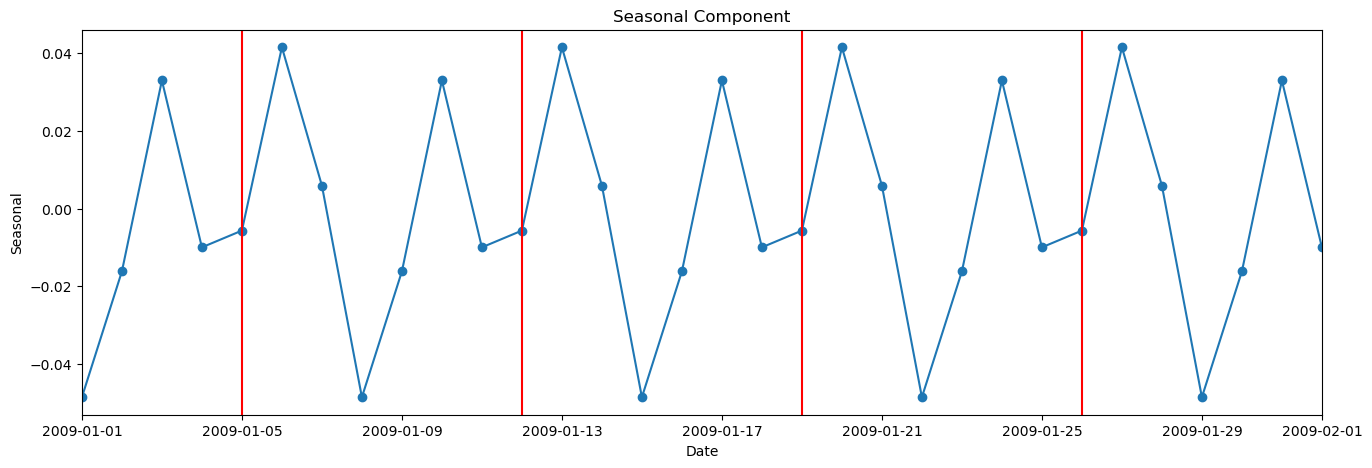

In [12]:
# Plot seasonality
plt.figure(figsize = [16,5])
# Plot seasonal component of the data
plt.plot(decomposed_data.seasonal, marker='o')
plt.xlim(pd.to_datetime('2009-01-01'), pd.to_datetime('2009-02-01'))
# Draw red lines on Mondays
plt.axvline(x=pd.to_datetime('2009-01-05'), color='red')
plt.axvline(x=pd.to_datetime('2009-01-12'), color='red')
plt.axvline(x=pd.to_datetime('2009-01-19'), color='red')
plt.axvline(x=pd.to_datetime('2009-01-26'), color='red');
# Plot info
plt.title('Seasonal Component')
plt.xlabel('Date')
plt.ylabel('Seasonal')
plt.show()

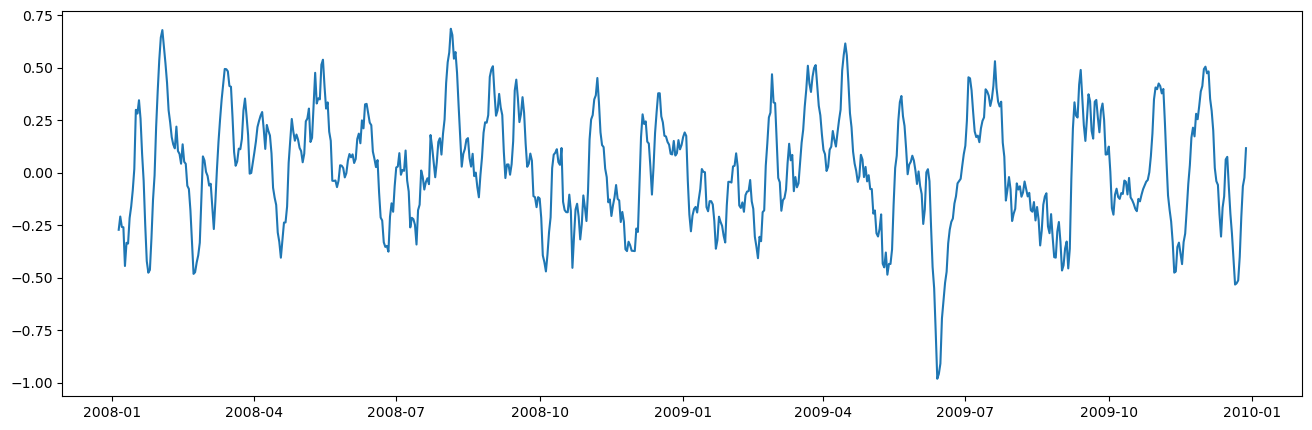

In [13]:
# Plot trends
plt.figure(figsize = [16,5])
plt.plot(decomposed_data.trend);

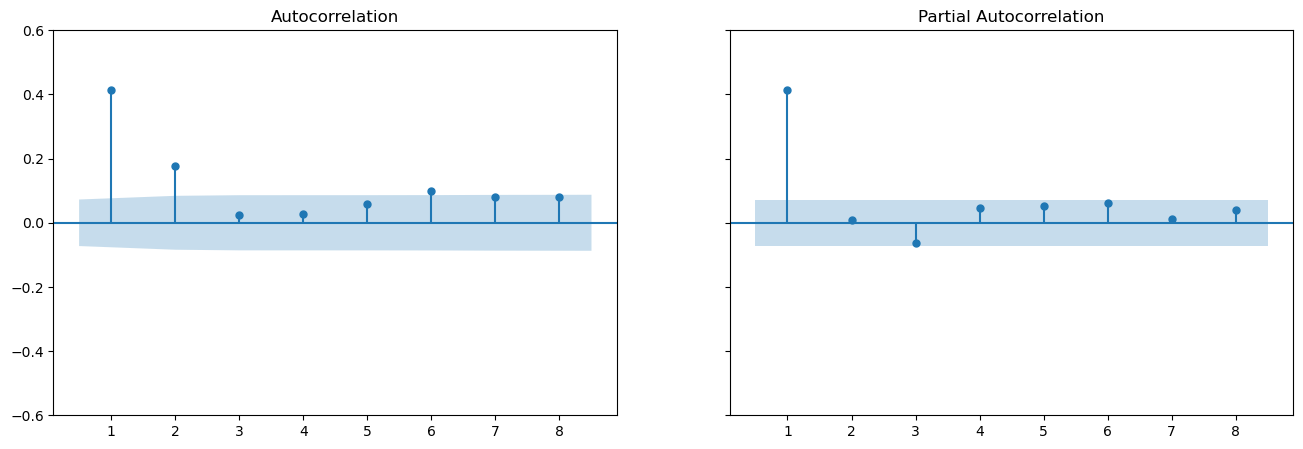

In [14]:
# Plot autocorrelation and partial autocorrelation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[16,5], sharey=True)
# Plot ACF to up to 8 lags to represent days
plot_acf(df_trans, lags=8, zero=False, ax=ax1)
# Plot PACF to 8 up to 8 lags to represent days
plot_pacf(df_trans, lags=8, zero=False,ax=ax2)
# Zoom in on y-axis to see points clearly
plt.ylim(-0.6, 0.6)
plt.show()

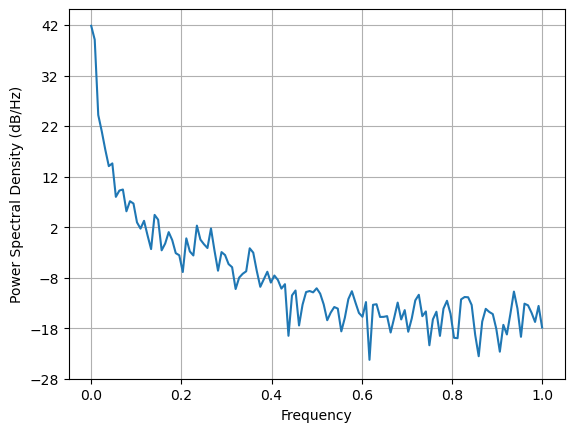

In [15]:
# Plot spectral density
plt.psd(df['Revenue'])
plt.show()

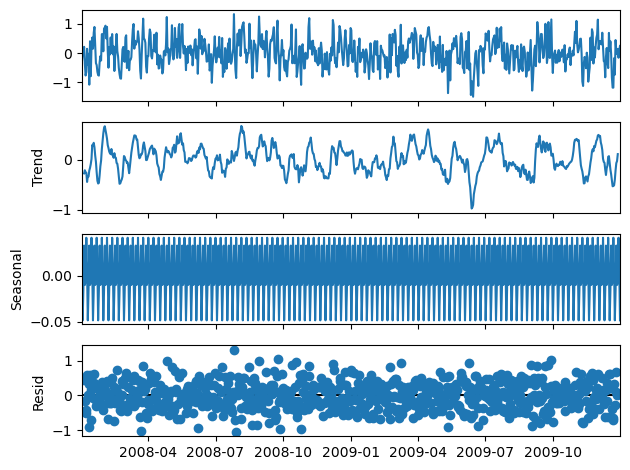

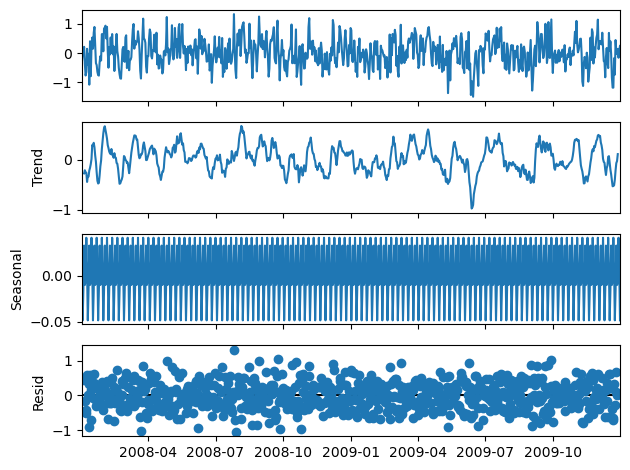

In [16]:
# Plot decomposed data
decomposed_data.plot()

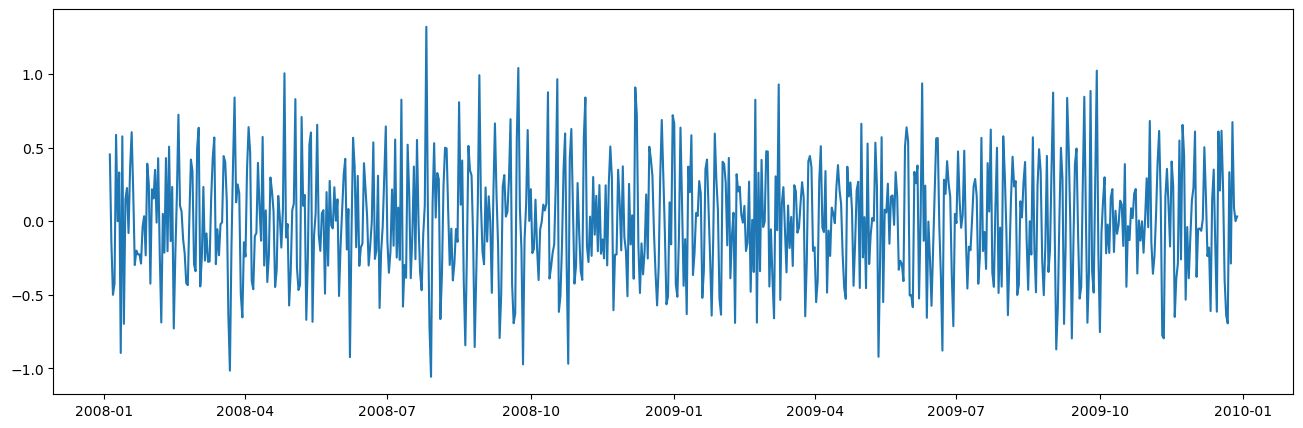

In [17]:
# Show lack of trends in residuals of decomposition
plt.figure(figsize = [16,5])
# Plot residual component of the data
plt.plot(decomposed_data.resid)

In [18]:
# Create ARIMA model
model = ARIMA(train, order=(1, 0, 0), freq='D')
results = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                Revenue   No. Observations:                  584
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -350.349
Date:                Wed, 20 Aug 2025   AIC                            706.698
Time:                        18:47:01   BIC                            719.808
Sample:                    01-02-2008   HQIC                           711.808
                         - 08-07-2009                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0328      0.031      1.063      0.288      -0.028       0.093
ar.L1          0.4079      0.038     10.748      0.000       0.333       0.482
sigma2         0.1943      0.012     15.948      0.0

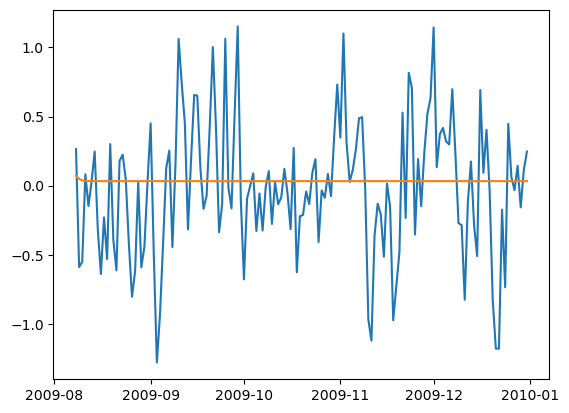

In [19]:
# Create forecast on ARIMA model
forecasted = results.get_prediction(start = 584, end = 729, dynamic = True)
plt.plot(test)
plt.plot(forecasted.predicted_mean)

In [20]:
# Print forecasted predicted mean
print(forecasted.predicted_mean)

2009-08-08    0.071071
2009-08-09    0.048405
2009-08-10    0.039159
2009-08-11    0.035388
2009-08-12    0.033850
                ...   
2009-12-27    0.032791
2009-12-28    0.032791
2009-12-29    0.032791
2009-12-30    0.032791
2009-12-31    0.032791
Freq: D, Name: predicted_mean, Length: 146, dtype: float64


In [21]:
# Create dataframe to hold forecasted differences values
forecast_temp = pd.DataFrame(forecasted.predicted_mean)
# Rename columns
forecast_temp.rename(columns={'predicted_mean' : 'Revenue'}, inplace=True)
# Concat a copy of train and forecasted values
forecast_df = pd.concat([train.copy(), forecast_temp.copy()])
# Invert the differences in daily revenue using cumsum
forecast_df = forecast_df.cumsum()
# Print forecast_df
forecast_df

,Revenue
2008-01-02,-0.292356
2008-01-03,-0.327772
2008-01-04,-0.339987
2008-01-05,-0.124888
2008-01-06,-0.491590
...,...
2009-12-27,24.033683
2009-12-28,24.066474
2009-12-29,24.099265
2009-12-30,24.132056


In [22]:
# Calculate confidence intervals from forecasted data
confidence_intervals = forecasted.conf_int()
# Print confidence intervals
confidence_intervals

,lower Revenue,upper Revenue
2009-08-08,-0.792856,0.934998
2009-08-09,-0.884621,0.981430
2009-08-10,-0.904871,0.983190
2009-08-11,-0.910461,0.981237
2009-08-12,-0.912301,0.980001
...,...,...
2009-12-27,-0.913421,0.979002
2009-12-28,-0.913421,0.979002
2009-12-29,-0.913421,0.979002
2009-12-30,-0.913421,0.979002


In [23]:
# Create dataframe to match the confidence intervals dataframe
previous_row = pd.DataFrame({'lower Revenue': [19.312734], 'upper Revenue' : [19.312734], 'Date' : ['2009-08-07']})
# Convert  date string to datetime and then set as index
previous_row['Date'] = pd.to_datetime(previous_row['Date'])
previous_row.set_index('Date', inplace=True)
# Print
previous_row

,lower Revenue,upper Revenue
Date,,
2009-08-07,19.312734,19.312734


In [24]:
# Concatenate  prior row and the confidence intervals data
confidence_intervals = pd.concat([previous_row, confidence_intervals])
# Untransform the confidence intervals using cumsum()
confidence_intervals = confidence_intervals.cumsum()
# Omit first row
confidence_intervals = confidence_intervals.loc['2009-08-08' : '2009-12-31']
# Print confidence intervals
confidence_intervals

,lower Revenue,upper Revenue
2009-08-08,18.519878,20.247732
2009-08-09,17.635257,21.229163
2009-08-10,16.730386,22.212353
2009-08-11,15.819925,23.193590
2009-08-12,14.907624,24.173592
...,...,...
2009-12-27,-110.230261,158.297627
2009-12-28,-111.143681,159.276629
2009-12-29,-112.057102,160.255632
2009-12-30,-112.970522,161.234634


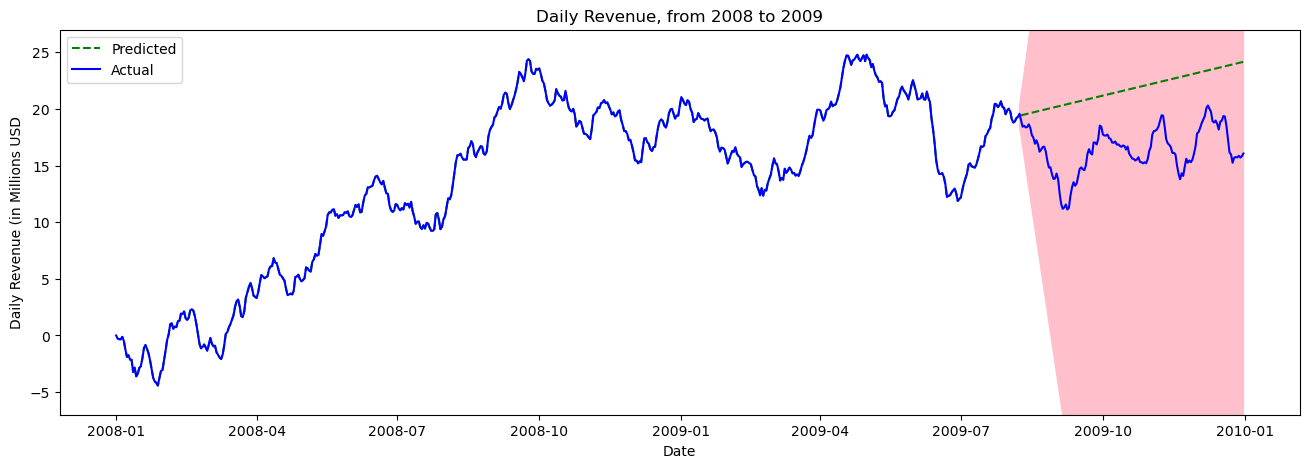

In [25]:
plt.figure(figsize = [16,5])
# Plot info
plt.title("Daily Revenue, from 2008 to 2009")
plt.xlabel("Date")
plt.ylabel("Daily Revenue (in Millions USD")
# Plot the forecasted data
plt.plot(forecast_df, color = 'green', linestyle = 'dashed')
# Plot the original data
plt.plot(df, color = 'blue')
# Plot the confidence intervals
plt.fill_between(confidence_intervals.index, confidence_intervals['lower Revenue'], confidence_intervals['upper Revenue'], color = 'pink')
# Keep the y-axis zoomed in
plt.ylim(-7, 27)
# Legend for plot
plt.legend(['Predicted', 'Actual'])
plt.show()

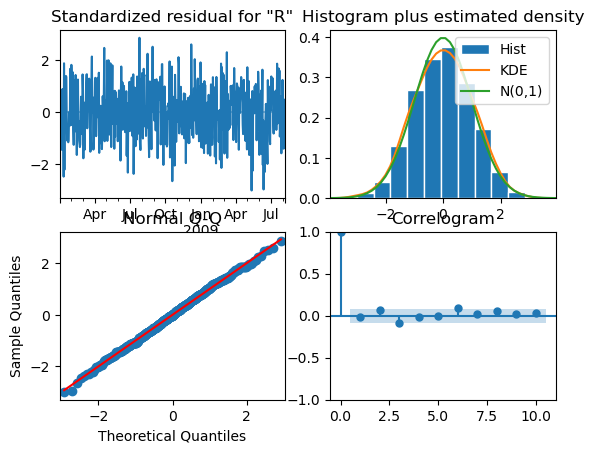

<Figure size 1600x1600 with 0 Axes>

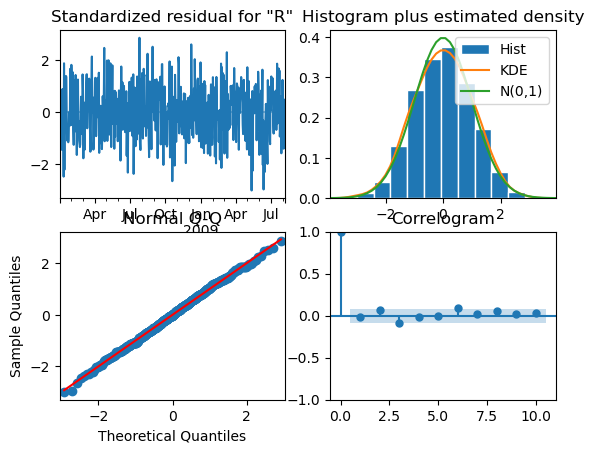

In [26]:
plt.figure(figsize = [16,16])
results.plot_diagnostics()

In [27]:
# pip install --upgrade scikit-learn

In [28]:
# Calculate root mean squared error of forecasted data vs observed data
rmse = root_mean_squared_error(df.loc['2009-08-08' : '2009-12-31'], forecast_df.Revenue.loc['2009-08-08' : '2009-12-31'])
print(f"The root mean squared error of this forecasting model is {round(rmse, 5)}")

The root mean squared error of this forecasting model is 5.7584


In [29]:
#jupyter nbconvert d213-task1.ipynb --to pdf